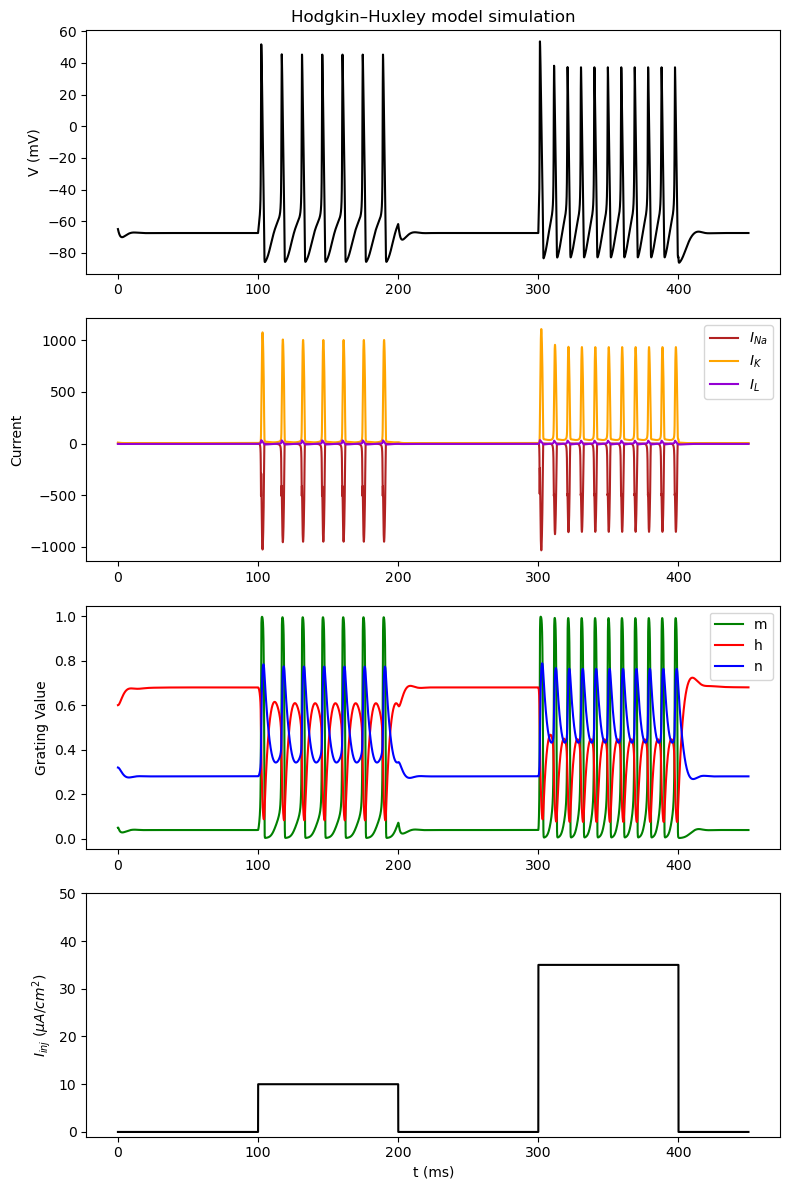

In [3]:
#--------------------Hodgkin-Huxley original model = elektrical stimuli--------------------#
#https://www.youtube.com/watch?v=qzhctJxdYyI
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

##########################
####### PARAMETERS #######
##########################
# from the original HH paper
# m = activation of Na
# h = inactivation of Na 
# n = activation of K
Cm  = 1.0                                                                        # uF/cm^2 membranecapacity 
g_Na = 120.0                                                                     # mS/cm^2 maximal conductantance Sodium
g_K  = 36.0                                                                      # mS/cm^2 maximal conductantance Potassium
g_L  = 0.3                                                                       # mS/cm^2 maximal conductantance Leak

E_Na = 60.0                                                                      # mV equilibrium potential Sodium (Nernst-potentiaal)
E_K  = -88.0                                                                     # mV equilibrium potential Potassium
E_L  = -54.4                                                                     # mV equilibrium potential Leak



##########################
######## STIMULUS ########
##########################
def alpha_n(V): return 0.01*(V+55)/(1-np.exp(-(V+55)/10))                        # opening speed K
def beta_n(V):  return 0.125*np.exp(-(V+65)/80)                                  # closing speed K
    
def alpha_m(V): return 0.1*(V+40)/(1-np.exp(-(V+40)/10))                         # alpha high high --> channel open 
def beta_m(V):  return 4*np.exp(-(V+65)/18)                                      # beta small --> m stays high 

def alpha_h(V): return 0.07*np.exp(-(V+65)/20)                                   # alpha small --> h slowly rises
def beta_h(V):  return 1/(1+np.exp(-(V+35)/10))                                  # beta big --> h goes down 

def I_Na(V, m, h): return g_Na * m**3 * h * (V - E_Na)                           # HH streams 
def I_K (V, n):    return g_K  * n**4 *     (V - E_K)
def I_L (V):       return g_L  *            (V - E_L)


##########################
########## TIME ##########
##########################
dt = 0.01                                                                        # ms time steps
T  = 450                                                                         # ms total simulation time
t = np.arange(0, T, dt)                                                          # array with all the timepoints

def I_inj (t):
    return 10 * (t>100) - 10 * (t>200) + 35 * (t>300) - 35 * (t>400)

def dALLdt(X, t):                                                                # HH equations
    V, m, h, n = X
    dVdt = (I_inj(t) - I_Na(V, m, h) - I_K(V, n) - I_L(V)) / Cm
    dndt = alpha_n(V) * (1-n) - beta_n(V)*n
    dmdt = alpha_m(V) * (1-m) - beta_m(V)*m
    dhdt = alpha_h(V) * (1-h) - beta_h(V)*h
    return dVdt, dmdt, dhdt, dndt

X = odeint(dALLdt, [-65, 0.05, 0.6, 0.32], t)                                    # starting values (resting) from paper
V = X[:, 0]
m = X[:, 1]
h = X[:, 2]
n = X[:, 3]

ina = I_Na(V, m, h)
ik  = I_K(V, n)
il  = I_L(V)

# plot
plt.figure(figsize=(8,12))

plt.subplot(4,1,1)                                                               # action potentials 
plt.title("Hodgkin–Huxley model simulation")
plt.plot(t, V, 'k')
plt.ylabel("V (mV)")

plt.subplot(4,1,2)                                                               # Ionic current per timepoint
plt.plot(t, ina, 'firebrick',  label='$I_{Na}$')
plt.plot(t, ik,  'orange',     label='$I_{K}$')
plt.plot(t, il,  'darkviolet', label='$I_{L}$')
plt.ylabel('Current')
plt.legend()

plt.subplot(4,1,3)                                                               # opening and closing of channels
plt.plot(t, m, 'g', label='m')
plt.plot(t, h, 'r', label='h')
plt.plot(t, n, 'b', label='n')
plt.ylabel('Grating Value')
plt.legend()


plt.subplot(4,1,4)                                                               # current through Channelrhodopsin when light is on 
plt.plot(t, I_inj(t), 'k')
plt.xlabel('t (ms)')
plt.ylabel('$I_{inj}$ ($\\mu{A}/cm^2$)')
plt.ylim(-1, 50)

plt.tight_layout()
plt.show()


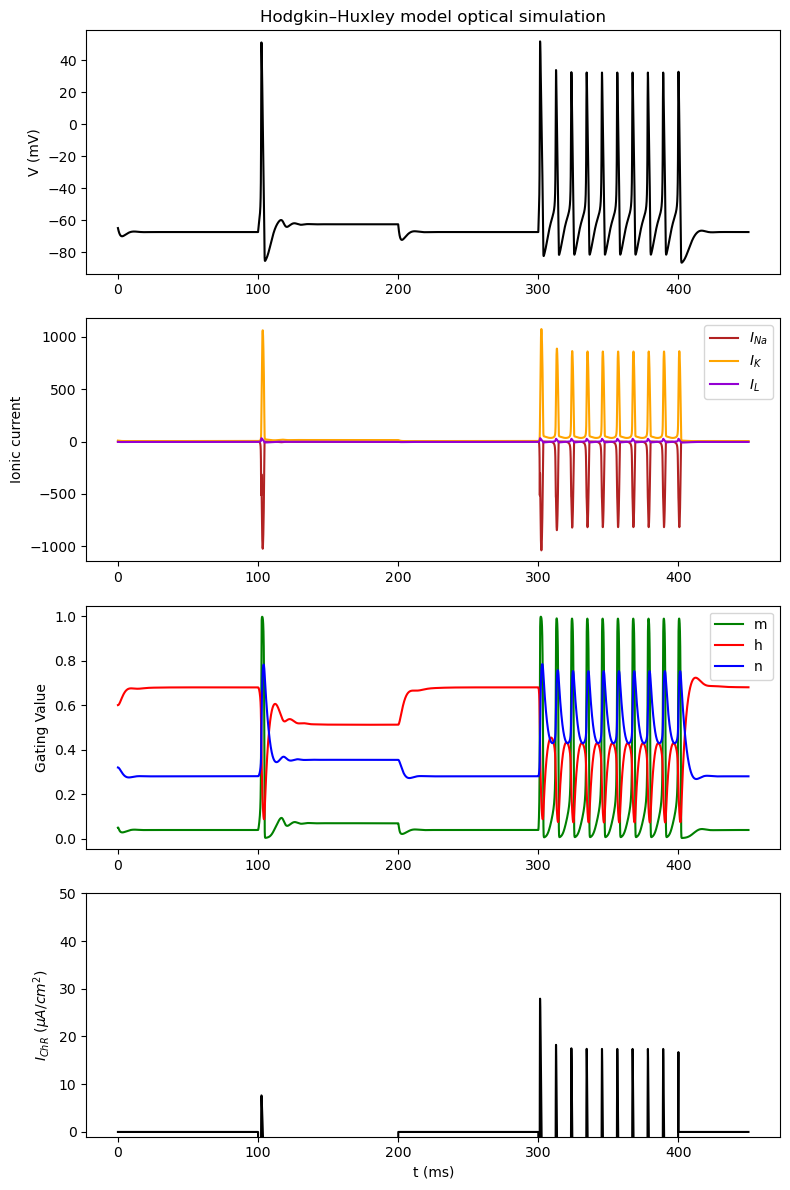

In [5]:
#--------------------Hodgkin-Huxley adapted model = optical stimuli--------------------#
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


##########################
####### PARAMETERS #######                                                       # from the original HH paper
##########################
# m = activation of Na (How many Na channels can open)
# h = inactivation of Na (How many Na channels can close)
# n = activation of K
Cm    = 1.0                                                                      # uF/cm^2 membranecapacity 
g_Na  = 120.0                                                                    # mS/cm^2 max conductace Na
g_K   = 36.0                                                                     # mS/cm^2 max conductance K
g_L   = 0.3                                                                      # mS/cm^2 max conductance Leak

E_Na  = 60.0                                                                     # mV equilibrium potential Na (Nernst-potentiaal)
E_K   = -88.0                                                                    # mV equilibrium potential K
E_L   = -54.4                                                                    # mV equilibrium potential Leak
E_ChR = 0.0                                                                      # mV equilibrium potential Channelrhodopsin


##########################
######## STIMULUS ########                                                       # formulas from the official HH paper
##########################                                                    
def alpha_n(V): return 0.01*(V+55)/(1-np.exp(-(V+55)/10))                        # opening speed K
def beta_n(V):  return 0.125*np.exp(-(V+65)/80)                                  # closing speed K
    
def alpha_m(V): return 0.1*(V+40)/(1-np.exp(-(V+40)/10))                         # alpha high high --> channel open 
def beta_m(V):  return 4*np.exp(-(V+65)/18)                                      # beta small --> m stays high

def alpha_h(V): return 0.07*np.exp(-(V+65)/20)                                   # alpha small --> h slowly rises 
def beta_h(V):  return 1/(1+np.exp(-(V+35)/10))                                  # beta big --> h goes down 

def I_Na(V, m, h): return g_Na * m**3 * h * (V - E_Na)                           # HH streams 
def I_K (V, n):    return g_K  * n**4 *     (V - E_K)
def I_L (V):       return g_L  *            (V - E_L)
def I_ChR(V, t):   return g_ChR(t)        * (V - E_ChR)                          # current through ChR when light shines on it, 
                                                                                 # V = -65 rest potential, during spike V = 0 
                                                                                 # I = g * (V - E)

##########################
########## TIME ##########
##########################
dt = 0.01                                                                        # ms time steps
T  = 450                                                                         # ms total simulation time 
t = np.arange(0, T, dt)                                                          # array with all the timepoints

def g_ChR(t):                                                                    # optical light on conductance
    return 0.15 * (t>100) * (t<200) + 0.54 * (t>300) * (t<400)                   # between 100-200ms g_ChR = 0.15 & between 300-400ms g_ChR = 0.54
                                                                                 # the same ratio as the elektrical stimulation 1:3,5

def dALLdt(X, t):                                                                # HH equations
    V, m, h, n = X
    dVdt = -(I_Na(V, m, h) + I_K(V, n) + I_L(V) + I_ChR(V, t)) / Cm
    dndt = alpha_n(V) * (1-n) - beta_n(V)*n
    dmdt = alpha_m(V) * (1-m) - beta_m(V)*m
    dhdt = alpha_h(V) * (1-h) - beta_h(V)*h
    return dVdt, dmdt, dhdt, dndt

X = odeint(dALLdt, [-65, 0.05, 0.6, 0.32], t)                                    # starting values (resting) from paper
V = X[:, 0]
m = X[:, 1]
h = X[:, 2]
n = X[:, 3]

ina = I_Na(V, m, h)
ik  = I_K (V, n)
il  = I_L (V)

##########################
########## PLOTS #########
##########################
plt.figure(figsize=(8,12))                                                       

plt.subplot(4,1,1)                                                               # action potentials 
plt.title("Hodgkin–Huxley model optical simulation")
plt.plot(t, V, 'k')
plt.ylabel("V (mV)")

plt.subplot(4,1,2)                                                               # Ionic current per timepoint
plt.plot(t, ina, 'firebrick',  label='$I_{Na}$')
plt.plot(t, ik,  'orange',     label='$I_{K}$')
plt.plot(t, il,  'darkviolet', label='$I_{L}$')
plt.ylabel('Ionic current')
plt.legend()

plt.subplot(4,1,3)                                                               # opening and closing of channels 
plt.plot(t, m, 'g', label='m')
plt.plot(t, h, 'r', label='h')
plt.plot(t, n, 'b', label='n')
plt.ylabel('Gating Value')
plt.legend()


plt.subplot(4,1,4)                                                               # current through Channelrhodopsin when light is on 
plt.plot(t, I_ChR(V, t), 'k')
plt.xlabel('t (ms)')
plt.ylabel('$I_{ChR}$ ($\\mu{A}/cm^2$)')
plt.ylim(-1, 50)

plt.tight_layout()
plt.show()